# Model Inference - Crack Detection Prediction

This notebook loads the trained model and performs predictions on all samples in the `samples` directory.

In [22]:
import os
import torch
import torch.nn as nn
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import torchvision.transforms as transforms

# Device configuration
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

BACKGROUND_CLASS = 0
LINE_CLASS = 255
SHAPE_CLASS = 125

BACKGROUND_INDEX = 0
LINE_INDEX = 1
SHAPE_INDEX = 2
NUM_CLASSES = 3

def decode_prediction_to_mask(pred_indices):
    mask = np.zeros_like(pred_indices, dtype=np.uint8)
    mask[pred_indices == LINE_INDEX] = LINE_CLASS
    mask[pred_indices == SHAPE_INDEX] = SHAPE_CLASS
    return mask

Using device: cpu


## Configuration

Set the paths for model, input samples, and output predictions

In [23]:
# Paths configuration
MODEL_PATH = "Generalized_dataset.pt"  # Path to saved model
SAMPLES_DIR = "samples_split/"  # Directory containing input images
OUTPUT_DIR = "predictions_split/"  # Directory to save predictions
IMG_SIZE = (1600, 1600)  # Model input size

# Create output directories
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/masks", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/overlays", exist_ok=True)

print(f"Model path: {MODEL_PATH}")
print(f"Input samples: {SAMPLES_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Model path: Generalized_dataset.pt
Input samples: samples_split/
Output directory: predictions_split/


## Load the Trained Model

In [24]:
import torch.nn as nn
import torch.nn.functional as F

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

class UNetCompact(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.enc1 = ConvBlock(1, 16)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = ConvBlock(16, 32)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = ConvBlock(32, 64)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = ConvBlock(64, 128)
        self.pool4 = nn.MaxPool2d(2)

        self.bottleneck = ConvBlock(128, 256)

        self.up4 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec4 = ConvBlock(256, 128)
        self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec3 = ConvBlock(128, 64)
        self.up2 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(64, 32)
        self.up1 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(32, 16)

        self.outc = nn.Conv2d(16, num_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))
        b = self.bottleneck(self.pool4(e4))

        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.outc(d1)

In [25]:
# Load the model
try:
    checkpoint = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)

    if isinstance(checkpoint, nn.Module):
        model = checkpoint
    elif isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        model = UNetCompact(num_classes=NUM_CLASSES)
        model.load_state_dict(checkpoint["model_state_dict"])
    elif isinstance(checkpoint, dict):
        model = UNetCompact(num_classes=NUM_CLASSES)
        model.load_state_dict(checkpoint)
    else:
        raise TypeError(f"Unsupported checkpoint type: {type(checkpoint)}")

    model = model.to(DEVICE)
    model.eval()
    print("✅ Model loaded successfully!")

    num_params = sum(p.numel() for p in model.parameters())
    print(f"Total Parameters: {num_params:,}")
except Exception as e:
    print(f"❌ Error loading model: {e}")
    raise

✅ Model loaded successfully!
Total Parameters: 1,943,795


## Define Preprocessing and Postprocessing Functions

In [26]:
def preprocess_image(image_path, img_size=(800, 800)):
    """
    Load and preprocess an image for model input
    
    Args:
        image_path: Path to the image file
        img_size: Target size for the image
    
    Returns:
        - Original image (for visualization)
        - Preprocessed tensor ready for model
        - Original dimensions
    """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Could not load image: {image_path}")
    
    original_size = img.shape
    img_resized = cv2.resize(img, img_size)
    img_tensor = torch.from_numpy(img_resized).float()
    img_tensor = img_tensor / 255.0
    img_tensor = img_tensor.unsqueeze(0).unsqueeze(0)
    
    return img, img_tensor, original_size


def postprocess_prediction(pred_tensor, original_size=None):
    """
    Convert model logits to a multiclass mask using the raw label values.
    
    Args:
        pred_tensor: Model output tensor with shape [B, C, H, W]
        original_size: Original image size to resize back to
    
    Returns:
        Multiclass mask as numpy array with values {0, 125, 255}
    """
    pred_indices = pred_tensor.argmax(dim=1).squeeze(0).cpu().detach().numpy().astype(np.uint8)
    pred_mask = decode_prediction_to_mask(pred_indices)
    
    if original_size is not None:
        pred_mask = cv2.resize(
            pred_mask,
            (original_size[1], original_size[0]),
            interpolation=cv2.INTER_NEAREST
        )
    
    return pred_mask


def mask_to_color(mask):
    """
    Convert a raw-label mask to an RGB visualization.
    """
    color_mask = np.zeros((*mask.shape, 3), dtype=np.uint8)
    color_mask[mask == SHAPE_CLASS] = [255, 215, 0]
    color_mask[mask == LINE_CLASS] = [255, 0, 0]
    return color_mask


def create_overlay(original_img, mask, alpha=0.5):
    """
    Create an overlay visualization for line and shape predictions.
    
    Args:
        original_img: Original grayscale image
        mask: Predicted multiclass mask with values {0, 125, 255}
        alpha: Transparency factor for overlay
    
    Returns:
        Overlay image (BGR format for cv2.imwrite)
    """
    if len(original_img.shape) == 2:
        img_bgr = cv2.cvtColor(original_img, cv2.COLOR_GRAY2BGR)
    else:
        img_bgr = original_img.copy()
    
    if mask.shape != original_img.shape:
        mask = cv2.resize(mask, (original_img.shape[1], original_img.shape[0]), interpolation=cv2.INTER_NEAREST)
    
    overlay = img_bgr.copy()
    overlay[mask == SHAPE_CLASS] = [0, 215, 255]
    overlay[mask == LINE_CLASS] = [0, 0, 255]
    
    return cv2.addWeighted(img_bgr, 1 - alpha, overlay, alpha, 0)

## Process All Samples

Run inference on all images in the samples directory

In [27]:
# Get all image files from samples directory
image_extensions = ['.jpg', '.jpeg', '.png', '.tif', '.tiff', '.bmp']
image_files = [f for f in os.listdir(SAMPLES_DIR) 
               if os.path.splitext(f)[1].lower() in image_extensions]

print(f"Found {len(image_files)} images to process")

if len(image_files) == 0:
    print("⚠️  No images found in samples directory!")
else:
    print("\nProcessing images...")
    
    results = []
    
    with torch.no_grad():
        for img_file in tqdm(image_files, desc="Processing"):
            try:
                img_path = os.path.join(SAMPLES_DIR, img_file)
                original_img, img_tensor, original_size = preprocess_image(img_path, IMG_SIZE)
                
                img_tensor = img_tensor.to(DEVICE)
                prediction = model(img_tensor)
                pred_mask = postprocess_prediction(prediction, original_size)
                overlay = create_overlay(original_img, pred_mask, alpha=0.4)
                
                base_name = os.path.splitext(img_file)[0]
                mask_path = os.path.join(OUTPUT_DIR, "masks", f"{base_name}_mask.png")
                cv2.imwrite(mask_path, pred_mask)
                
                overlay_path = os.path.join(OUTPUT_DIR, "overlays", f"{base_name}_overlay.png")
                cv2.imwrite(overlay_path, overlay)
                
                line_percentage = (pred_mask == LINE_CLASS).sum() / pred_mask.size * 100
                shape_percentage = (pred_mask == SHAPE_CLASS).sum() / pred_mask.size * 100
                defect_percentage = line_percentage + shape_percentage
                
                results.append({
                    'filename': img_file,
                    'line_percentage': line_percentage,
                    'shape_percentage': shape_percentage,
                    'defect_percentage': defect_percentage,
                    'has_crack': line_percentage > 0.1,
                    'has_shape': shape_percentage > 0.1
                })
                
            except Exception as e:
                print(f"\n❌ Error processing {img_file}: {e}")
                continue
    
    print(f"\n✅ Processing complete! Results saved to {OUTPUT_DIR}")

Found 192 images to process

Processing images...


Processing: 100%|██████████| 192/192 [04:51<00:00,  1.52s/it]


✅ Processing complete! Results saved to predictions_split/


## Results Summary

In [7]:
# Print summary statistics
if results:
    print("\n" + "="*60)
    print("PREDICTION SUMMARY")
    print("="*60)
    
    total_images = len(results)
    images_with_cracks = sum(1 for r in results if r['has_crack'])
    images_with_shapes = sum(1 for r in results if r['has_shape'])
    avg_line = sum(r['line_percentage'] for r in results) / total_images
    avg_shape = sum(r['shape_percentage'] for r in results) / total_images
    avg_defect = sum(r['defect_percentage'] for r in results) / total_images
    
    print(f"\nTotal images processed: {total_images}")
    print(f"Images with detected cracks: {images_with_cracks} ({images_with_cracks/total_images*100:.1f}%)")
    print(f"Images with detected shapes: {images_with_shapes} ({images_with_shapes/total_images*100:.1f}%)")
    print(f"Average crack coverage: {avg_line:.2f}%")
    print(f"Average shape coverage: {avg_shape:.2f}%")
    print(f"Average total defect coverage: {avg_defect:.2f}%")
    
    print("\n" + "-"*60)
    print("Top 5 images with most detected cracks:")
    print("-"*60)
    sorted_results = sorted(results, key=lambda x: x['line_percentage'], reverse=True)
    for i, result in enumerate(sorted_results[:5], 1):
        print(
            f"{i}. {result['filename']}: "
            f"{result['line_percentage']:.2f}% crack, "
            f"{result['shape_percentage']:.2f}% shape"
        )
    
    print("\n" + "="*60)


PREDICTION SUMMARY

Total images processed: 12
Images with detected cracks: 11 (91.7%)
Images with detected shapes: 12 (100.0%)
Average crack coverage: 1.70%
Average shape coverage: 45.32%
Average total defect coverage: 47.02%

------------------------------------------------------------
Top 5 images with most detected cracks:
------------------------------------------------------------
1. front_4292_6.png: 5.92% crack, 6.24% shape
2. front_2203_4A_220kv.png: 3.40% crack, 5.30% shape
3. front_1208_3A_220kv.png: 3.36% crack, 15.21% shape
4. front_1100_3A_135kv.png: 2.51% crack, 58.79% shape
5. front_1274_4A_135kv.png: 2.18% crack, 56.69% shape



## Visualize Sample Predictions

Display a few sample predictions

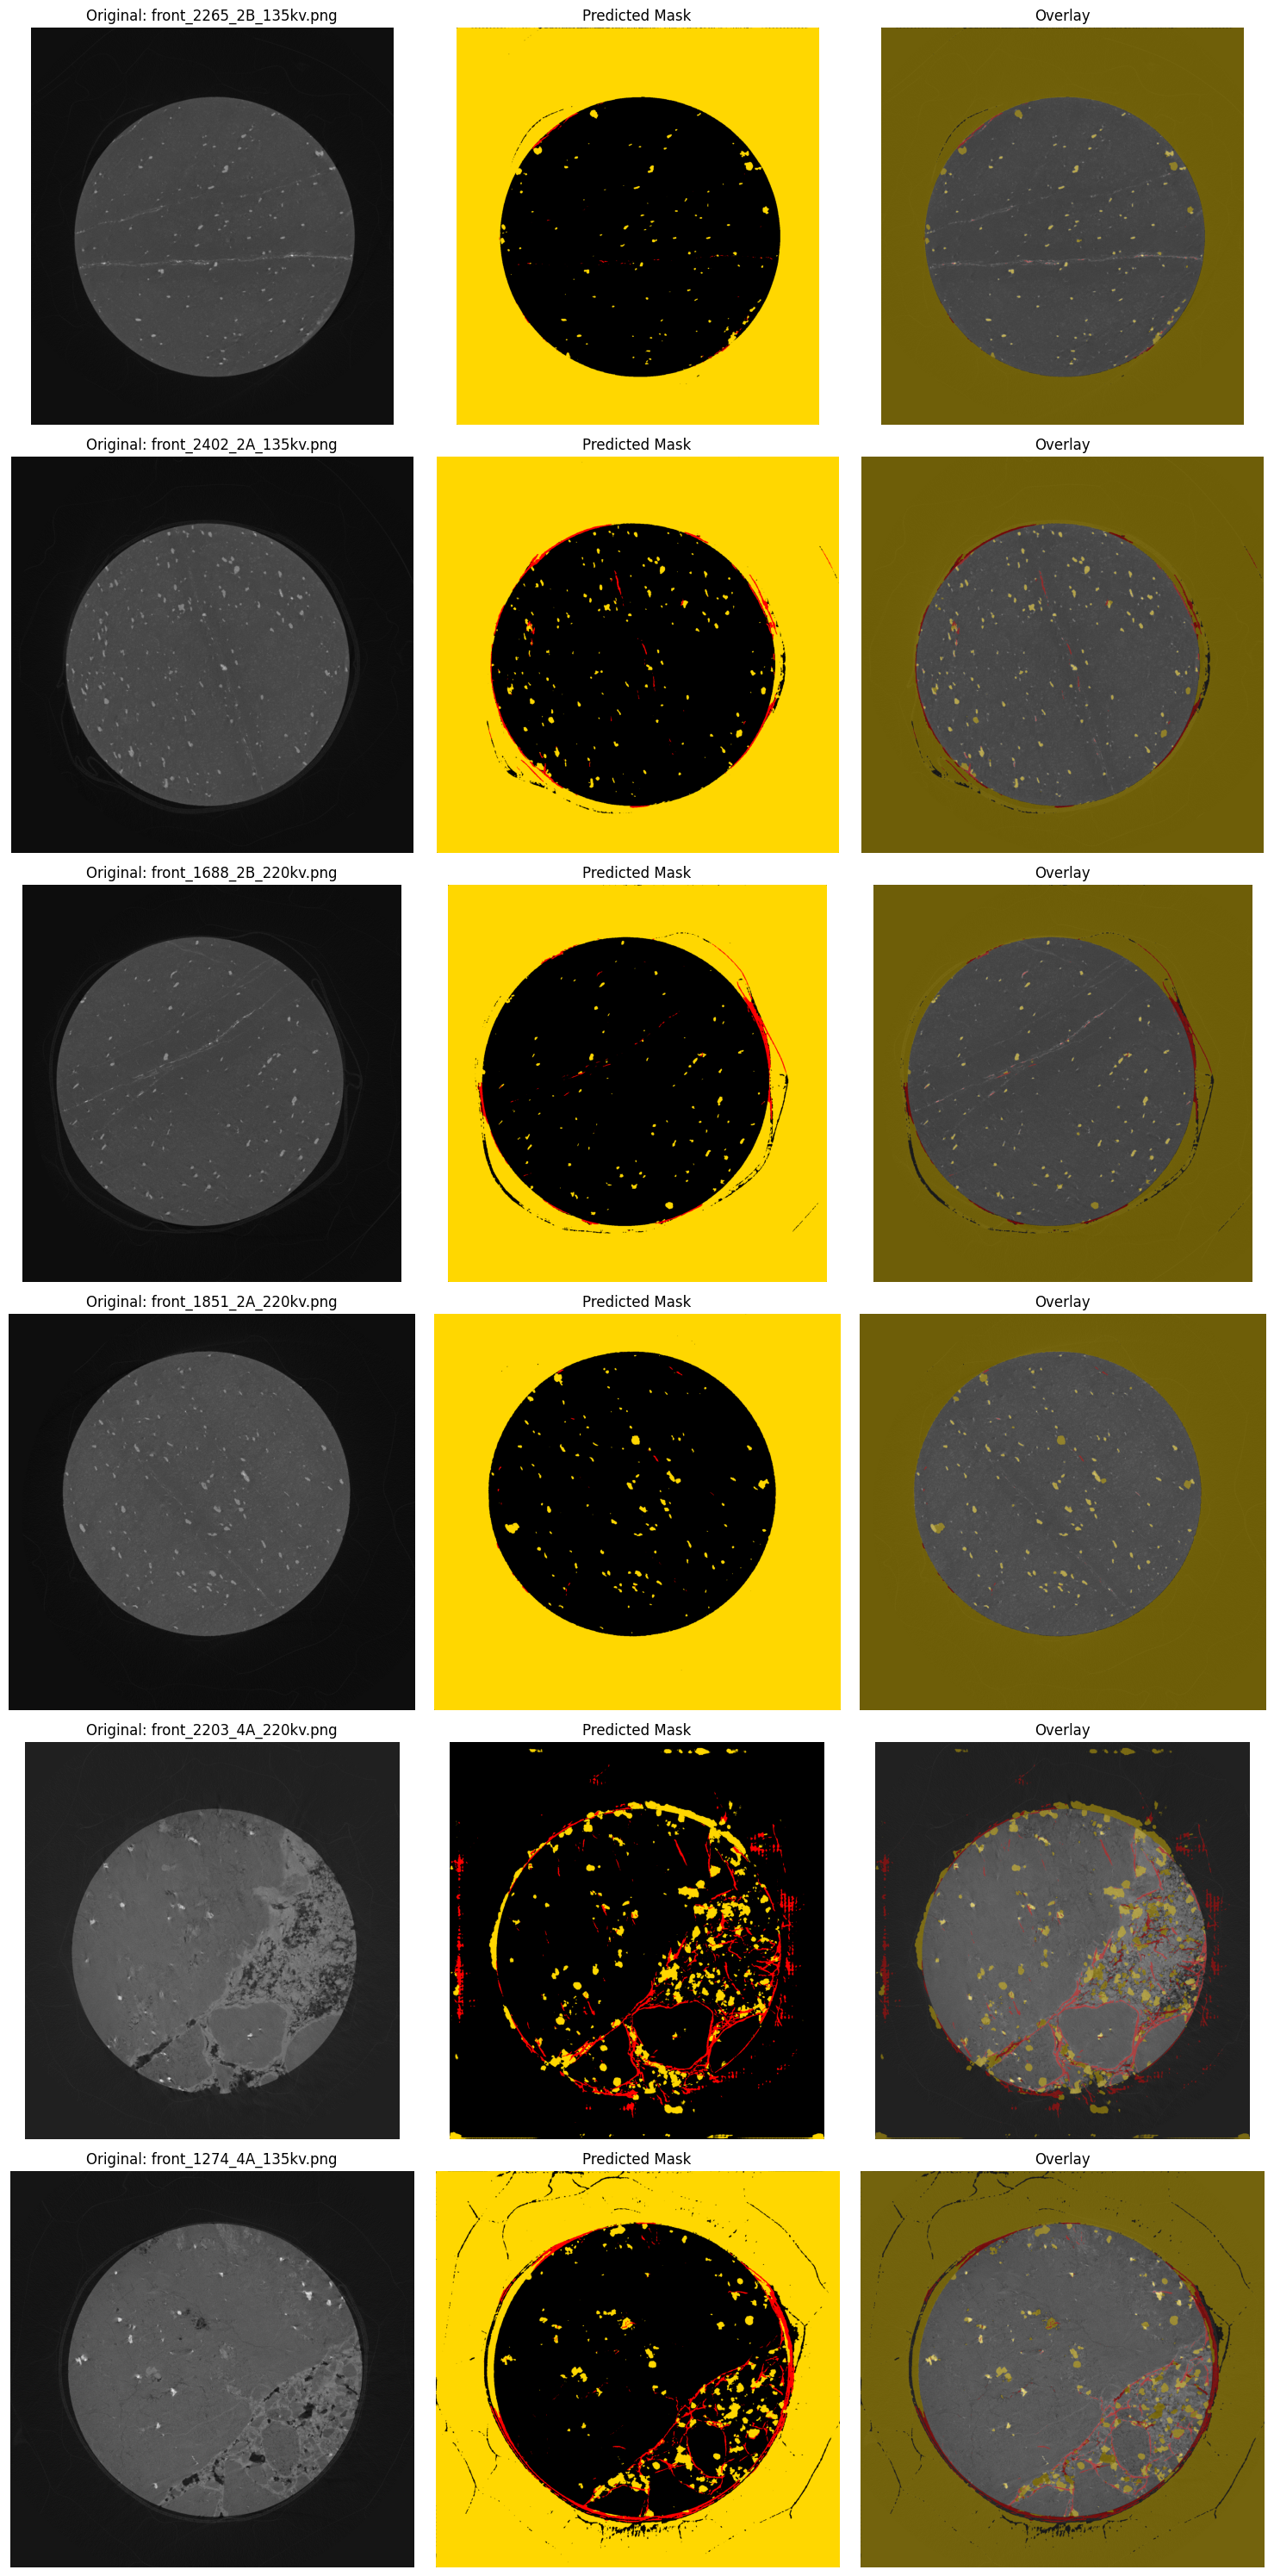

✅ Visualization saved to predictions//visualization_samples.png


In [8]:
# Visualize some sample predictions
num_samples = min(6, len(image_files))

if num_samples > 0:
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    for idx in range(num_samples):
        img_file = image_files[idx]
        base_name = os.path.splitext(img_file)[0]
        
        original_path = os.path.join(SAMPLES_DIR, img_file)
        original = cv2.imread(original_path, cv2.IMREAD_GRAYSCALE)
        
        mask_path = os.path.join(OUTPUT_DIR, "masks", f"{base_name}_mask.png")
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask_rgb = mask_to_color(mask)
        
        overlay_path = os.path.join(OUTPUT_DIR, "overlays", f"{base_name}_overlay.png")
        overlay = cv2.imread(overlay_path)
        overlay_rgb = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)
        
        axes[idx, 0].imshow(original, cmap='gray')
        axes[idx, 0].set_title(f"Original: {img_file}")
        axes[idx, 0].axis('off')
        
        axes[idx, 1].imshow(mask_rgb)
        axes[idx, 1].set_title("Predicted Mask")
        axes[idx, 1].axis('off')
        
        axes[idx, 2].imshow(overlay_rgb)
        axes[idx, 2].set_title("Overlay")
        axes[idx, 2].axis('off')
    
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/visualization_samples.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Visualization saved to {OUTPUT_DIR}/visualization_samples.png")

## Export Results to CSV (Optional)

In [9]:
# Export results to CSV file
import csv

if results:
    csv_path = os.path.join(OUTPUT_DIR, "prediction_results.csv")
    
    with open(csv_path, 'w', newline='') as csvfile:
        fieldnames = [
            'filename',
            'line_percentage',
            'shape_percentage',
            'defect_percentage',
            'has_crack',
            'has_shape'
        ]
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        
        writer.writeheader()
        for result in results:
            writer.writerow(result)
    
    print(f"✅ Results exported to {csv_path}")

✅ Results exported to predictions/prediction_results.csv
